In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()

In [20]:
def read_data(file_name):
    data = []

    with open(f"Multi_data/{file_name}.txt") as f:
        for line in f:
            if line.startswith("%"):
                continue
            parts = line.split()
            data.append([float(x) for x in parts])

    data = np.array(data)

    # columns
    C_par = data[:, 0]

    # unique batches
    unique_C = np.unique(C_par)

    batches = []

    for c in unique_C:
        batch = data[C_par == c]
        batch = batch[np.argsort(batch[:, 1])]  # sort by time
        batches.append(batch)

    return batches

path = f'test_data'

data = read_data(path)
dict_data = {
    'par': [b[:, 0] for b in data],
    't': [b[:, 1] for b in data],
    'E_cell': [b[:, 2] for b in data],
    'I_cell': [b[:, 3] for b in data],
    'Rx_cell': [b[:, 4] for b in data],
    'u_cell': [b[:, 5] for b in data]
}

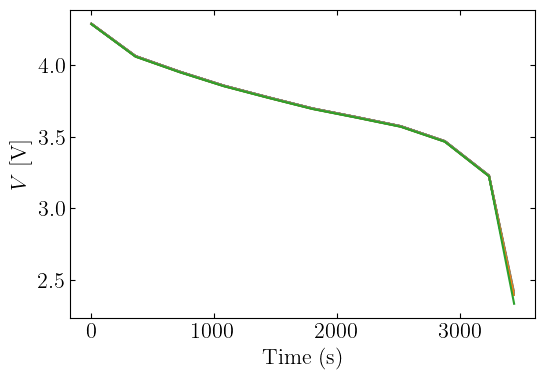

In [21]:
fig = plt.figure(figsize=(6, 4))
for i, batch in enumerate(data):
    # batch[:, 4] is Current, batch[:, 1] is t, batch[:, 2] is V_cell
    u = batch[0, -1]  # take first timestep's value for label

    plt.plot(batch[:, 1], batch[:, 2], label=fr'$u={u*1e6:.1f} $ $\mu m$')

plt.xlabel("Time (s)")
plt.ylabel("$V$ [V]")
# plt.legend()
plt.show()

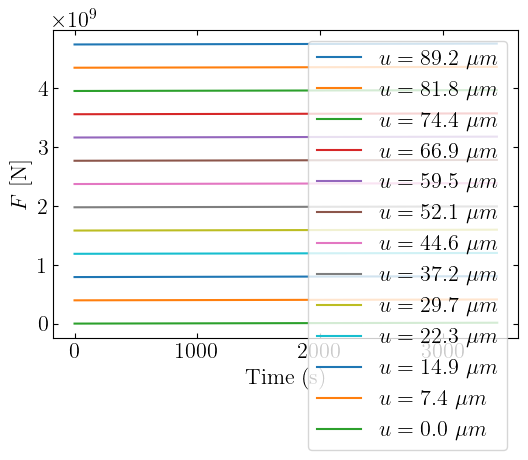

In [22]:
fig = plt.figure(figsize=(6, 4))
for i, batch in enumerate(data):
    # batch[:, 4] is Current, batch[:, 1] is t, batch[:, 2] is V_cell
    u = batch[0, -1]  # take first timestep's value for label
    t = batch[:, 1]
    val = batch[:, 4]
    plt.plot(t, val, label=fr'$u={u*1e6:.1f} $ $\mu m$')

plt.xlabel("Time (s)")
plt.ylabel("$F$ [N]")
plt.legend()
plt.show()